# Trực quan số lượng

In [2]:
!pip install pandas matplotlib seaborn plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 6.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 6.0 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 7.1 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 7.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 7.3 MB/s  0:00:01

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ----------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Viet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Tổng số khách hàng rời bỏ: 2037
Tỷ lệ rời bỏ tổng thể: 20.37%

--- Tỷ lệ rời bỏ theo các đặc điểm ---
        count  churn_count  churn_rate (%)
gender                                    
Female   4543         1139       25.071539
Male     5457          898       16.455928
         count  churn_count  churn_rate (%)
country                                    
France    5014          810       16.154767
Germany   2509          814       32.443204
Spain     2477          413       16.673395
                 count  churn_count  churn_rate (%)
products_number                                    
1                 5084         1409       27.714398
2                 4590          348        7.581699
3                  266          220       82.706767
4                   60           60      100.000000
             count  churn_count  churn_rate (%)
credit_card                                    
0             2945          613       20.814941
1             7055         1424       20.184266
  

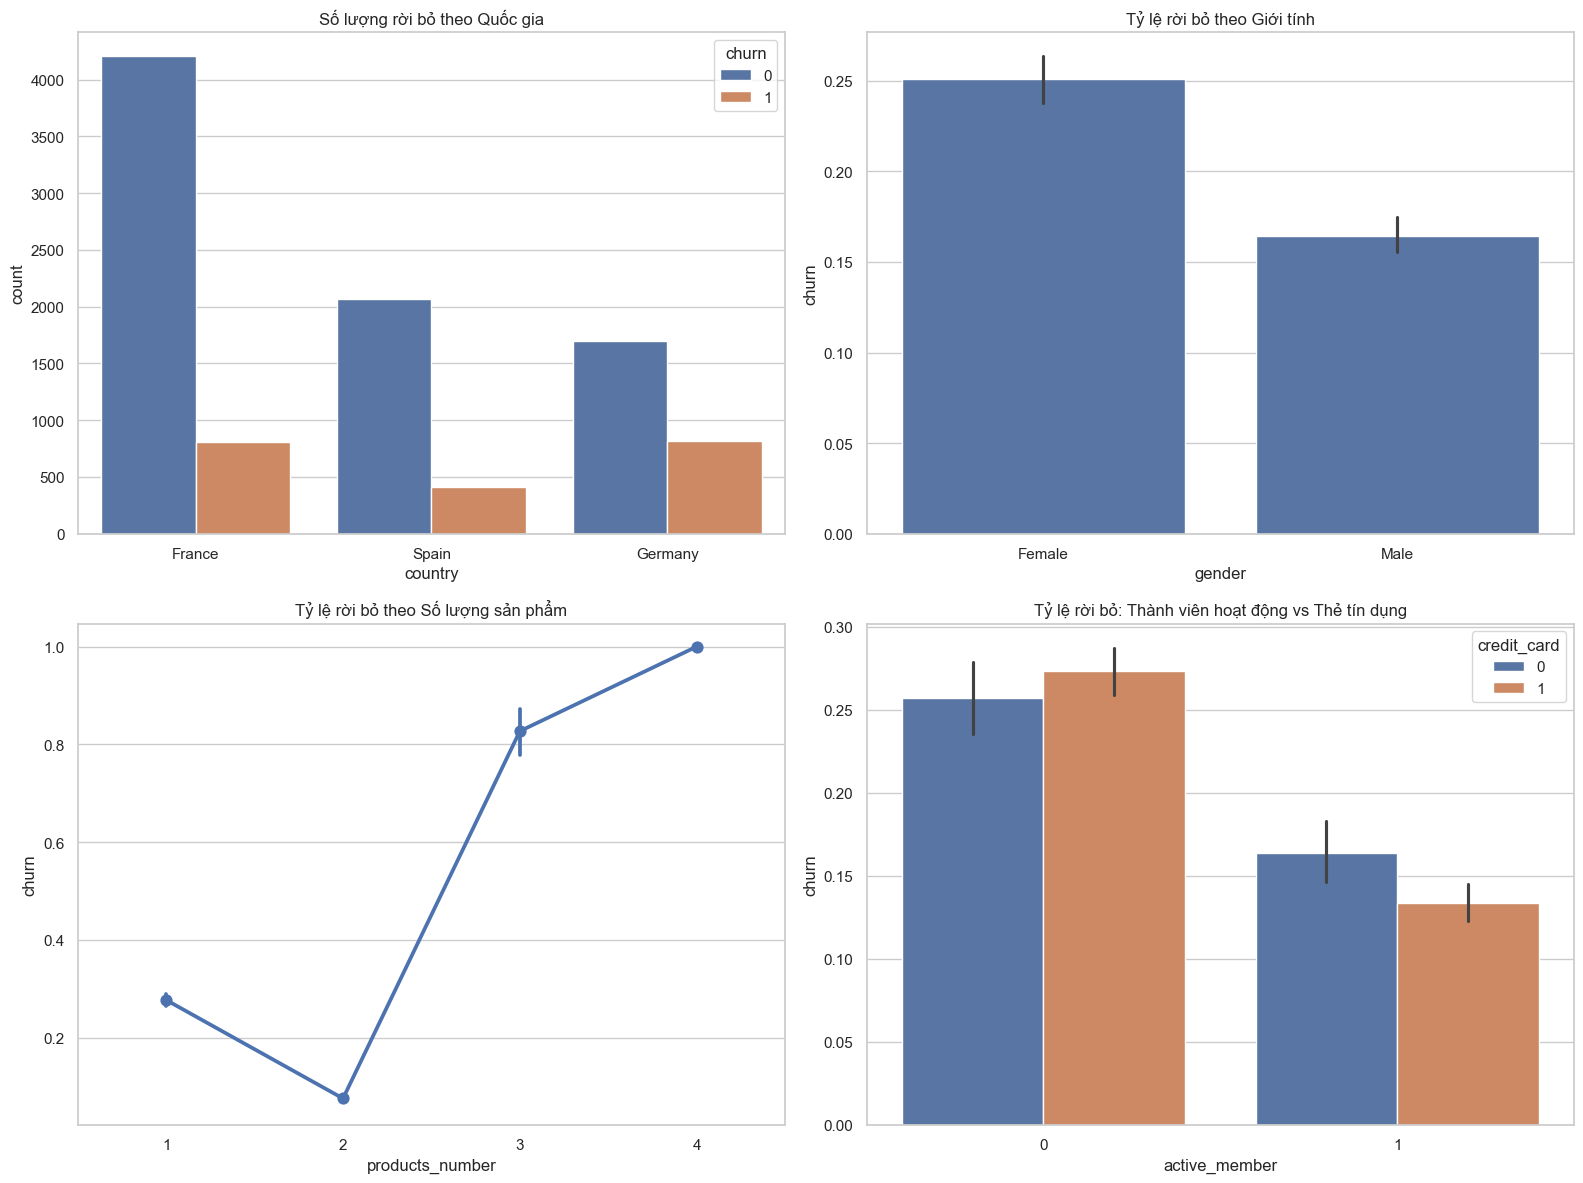

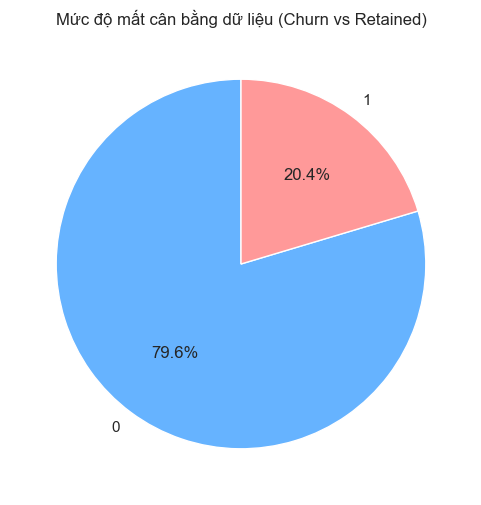

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'textinfo': 'value+percent initial',
              'type': 'funnel',
              'x': [10000, 7055, 5151, 7963],
              'y': [Tổng số khách hàng, Có thẻ tín dụng, Thành viên hoạt động,
                    Khách hàng ở lại (Non-Churn)]}],
    'layout': {'template': '...', 'title': {'text': 'Biểu đồ phễu giữ chân khách hàng'}}
})

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# 1. Đọc dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- PHẦN 1: TÍNH TOÁN VÀ PHÂN TÍCH SỐ LIỆU ---

# Tổng số lượng khách hàng rời bỏ (Churn)
total_churn = df['churn'].sum()
churn_rate = (total_churn / len(df)) * 100

print(f"Tổng số khách hàng rời bỏ: {total_churn}")
print(f"Tỷ lệ rời bỏ tổng thể: {churn_rate:.2f}%")

# Hàm tính tỷ lệ churn theo nhóm
def get_churn_stats(column):
    stats = df.groupby(column)['churn'].agg(['count', 'sum'])
    stats['churn_rate (%)'] = (stats['sum'] / stats['count']) * 100
    return stats.rename(columns={'sum': 'churn_count'})

print("\n--- Tỷ lệ rời bỏ theo các đặc điểm ---")
print(get_churn_stats('gender'))
print(get_churn_stats('country'))
print(get_churn_stats('products_number'))
print(get_churn_stats('credit_card'))
print(get_churn_stats('active_member'))

# --- PHẦN 2: TRỰC QUAN HÓA DỮ LIỆU ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Phân tích Churn theo Giới tính và Quốc gia
sns.countplot(data=df, x='country', hue='churn', ax=axes[0, 0])
axes[0, 0].set_title('Số lượng rời bỏ theo Quốc gia')

sns.barplot(data=df, x='gender', y='churn', ax=axes[0, 1])
axes[0, 1].set_title('Tỷ lệ rời bỏ theo Giới tính')

# 2. Phân tích theo Thẻ tín dụng và Trạng thái hoạt động
sns.pointplot(data=df, x='products_number', y='churn', ax=axes[1, 0])
axes[1, 0].set_title('Tỷ lệ rời bỏ theo Số lượng sản phẩm')

sns.barplot(data=df, x='active_member', y='churn', hue='credit_card', ax=axes[1, 1])
axes[1, 1].set_title('Tỷ lệ rời bỏ: Thành viên hoạt động vs Thẻ tín dụng')

plt.tight_layout()
plt.show()

# --- PHẦN 3: ĐÁNH GIÁ MỨC ĐỘ MẤT CÂN BẰNG (IMBALANCE) ---
plt.figure(figsize=(6, 6))
df['churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Mức độ mất cân bằng dữ liệu (Churn vs Retained)')
plt.ylabel('')
plt.show()

# --- PHẦN 4: BIỂU ĐỒ PHỄU (CHURN FUNNEL) ---
# Giả định quy trình: Tổng khách -> Có thẻ tín dụng -> Thành viên hoạt động -> Khách hàng ở lại
funnel_data = {
    "Stage": ["Tổng số khách hàng", "Có thẻ tín dụng", "Thành viên hoạt động", "Khách hàng ở lại (Non-Churn)"],
    "Value": [
        len(df),
        df['credit_card'].sum(),
        df['active_member'].sum(),
        len(df) - df['churn'].sum()
    ]
}

fig_funnel = go.Figure(go.Funnel(
    y=funnel_data["Stage"],
    x=funnel_data["Value"],
    textinfo="value+percent initial"
))
fig_funnel.update_layout(title_text='Biểu đồ phễu giữ chân khách hàng')